# examine [OII] emission line SNR 
With the ultimate goal of estimating the redshift success rate with 15min exposure times. 

In [1]:
import numpy as np 
from astropy.table import Table, join

In [2]:
# --- plotting ---
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['axes.xmargin'] = 1
mpl.rcParams['xtick.labelsize'] = 'x-large'
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.major.width'] = 1.5
mpl.rcParams['ytick.labelsize'] = 'x-large'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.major.width'] = 1.5
mpl.rcParams['legend.frameon'] = False

# LAM1D catalog

In [3]:
lam1d = Table.read('/Users/hahnchanghoon/data/pfs/lam1d_s25a_matched_run21_run22.fits')

In [4]:
# internal LAM 1D redshift quality cut
# only with good LAM 1D redshifts
best_lam = ((lam1d['probaGalaxy'] > 0.99) & 
           (lam1d['redshiftProba'] > 0.99) & 
           (lam1d['redshiftError'] < 0.01))
print('LAM-BEST %.3f' % np.mean(best_lam))

LAM-BEST 0.637


In [5]:
# compile HSC photometry
# extinction corrected magnitudes 
g_mag = lam1d['g_cmodel_mag'] - lam1d['a_g']
r_mag = lam1d['r_cmodel_mag'] - lam1d['a_r']
i_mag = lam1d['i_cmodel_mag'] - lam1d['a_i']
z_mag = lam1d['z_cmodel_mag'] - lam1d['a_z']

# OII catalog
Includes nearly all objects with LAM1D redshift $0.6 < z < 1.6$

In [6]:
# OII table from Jingjing's google drive 
oii = Table.read('/Users/hahnchanghoon/data/pfs/lam1d_oii_table_flux_sn_full_v2.fits')

In [7]:
lam1d_oii = join(lam1d, oii['obj_id', 'oii_flux', 'oii sn2', 'oii noise', 'oii_sn pixel #'], keys=['obj_id'], join_type='left') 
mask_oii = lam1d_oii['oii_flux'].mask 

In [8]:
oii_snr = lam1d_oii['oii_flux'] / lam1d_oii['oii noise']

(0.0, 10.0)

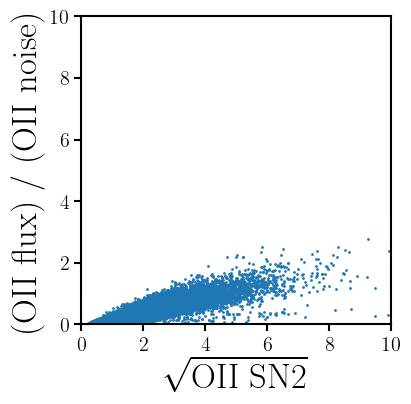

In [9]:
fig = plt.figure(figsize=(4,4))
sub = fig.add_subplot(111)
sub.scatter(np.sqrt(oii['oii sn2']) / oii['oii_sn pixel #'], oii['oii_flux'] / oii['oii noise'], c='C0', s=1)
sub.set_xlabel(r'$\sqrt{\rm OII~SN2}$', fontsize=25)
sub.set_xlim(0., 10)
sub.set_ylabel(r'(OII flux) / (OII noise)', fontsize=25)
sub.set_ylim(0., 10)

In [10]:
oii_snr = np.sqrt(lam1d_oii['oii sn2']) / lam1d_oii['oii_sn pixel #']

/var/folders/w7/p2lcz8lj0m39n1ywl2_s0_j40000gp/T/ipykernel_58578/422246478.py:3: RuntimeWarning: divide by zero encountered in log10
  hb = sub.scatter(lam1d_oii['redshift'][~mask_oii], np.log10(oii_snr[~mask_oii]), c=lam1d_oii['t_exp_total'][~mask_oii]/60., s=1, vmin=15., vmax=60, cmap='Spectral_r')


Text(0, 0.5, 'exposure time (minutes)')

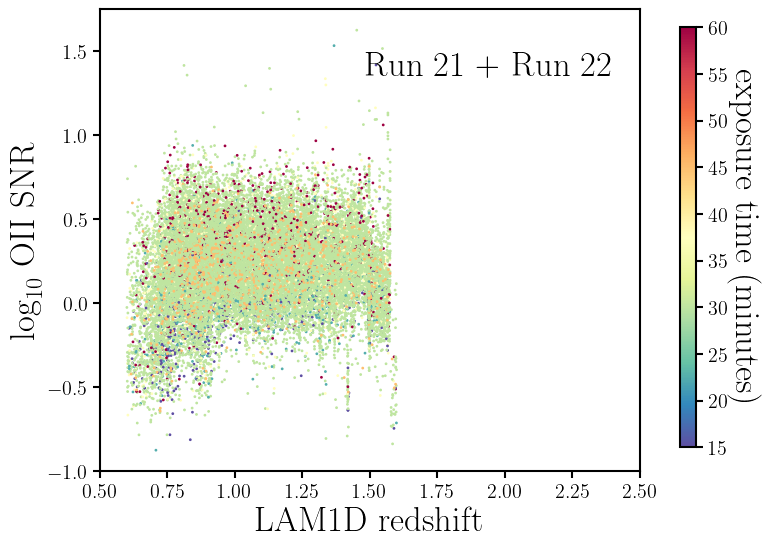

In [13]:
fig = plt.figure(figsize=(8,6))
sub = fig.add_subplot(111)
hb = sub.scatter(lam1d_oii['redshift'][~mask_oii], np.log10(oii_snr[~mask_oii]), c=lam1d_oii['t_exp_total'][~mask_oii]/60., s=1, vmin=15., vmax=60, cmap='Spectral_r')

sub.text(2.4, 1.5, 'Run 21 + Run 22', ha='right', va='top', fontsize=25)
sub.set_xlabel('LAM1D redshift', fontsize=25)
sub.set_xlim(0.5, 2.5)
sub.set_ylabel(r'$\log_{10}$ OII SNR', fontsize=25)

fig.subplots_adjust(wspace=0.1, right=0.8)

cbar_ax = fig.add_axes([0.85, 0.15, 0.02, 0.7])
cbar = fig.colorbar(hb, cax=cbar_ax)
cbar.ax.set_ylabel(r'exposure time (minutes)', labelpad=25, fontsize=25, rotation=270)

0.19108979976605395
0.250165354002131
0.2579838640214759
0.22241865964278434


/var/folders/w7/p2lcz8lj0m39n1ywl2_s0_j40000gp/T/ipykernel_58578/291530331.py:5: RuntimeWarning: divide by zero encountered in log10
  _ = sub.hist(np.log10(oii_snr)[_zslice], range=(-2, 1), bins=40, alpha=0.5, density=True, label=r'$%.2f < z < %.2f$' % (_z - 0.1, _z+0.1))
/var/folders/w7/p2lcz8lj0m39n1ywl2_s0_j40000gp/T/ipykernel_58578/291530331.py:6: RuntimeWarning: divide by zero encountered in log10
  print(np.median(np.log10(oii_snr)[_zslice]))


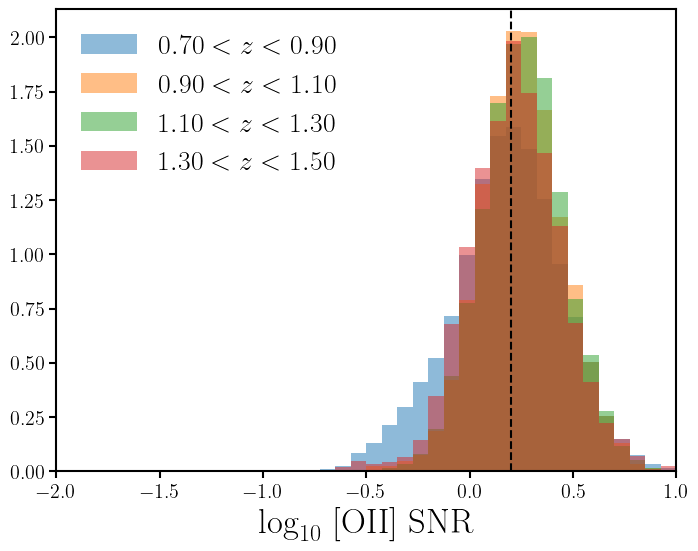

In [17]:
fig = plt.figure(figsize=(8,6))
sub = fig.add_subplot(111)
for _z in [0.8, 1., 1.2, 1.4]: 
    _zslice = (lam1d_oii['redshift'] > _z - 0.1) & (lam1d_oii['redshift'] < _z + 0.1) & ~mask_oii
    _ = sub.hist(np.log10(oii_snr)[_zslice], range=(-2, 1), bins=40, alpha=0.5, density=True, label=r'$%.2f < z < %.2f$' % (_z - 0.1, _z+0.1))
    print(np.median(np.log10(oii_snr)[_zslice]))
sub.axvline(0.2, color='k', linestyle='--')
sub.set_xlabel(r'$\log_{10}$ [OII] SNR', fontsize=25)
sub.set_xlim(-2., 1)
sub.legend(loc='upper left', fontsize=20)

# How does the $z$ success rate shift if we *naively* scale the exposure times down

/var/folders/w7/p2lcz8lj0m39n1ywl2_s0_j40000gp/T/ipykernel_58578/2850012043.py:10: RuntimeWarning: divide by zero encountered in log10
  c=np.log10(oii_snr[zlim]), s=1, vmin=-1, vmax=1.5, cmap='afmhot_r')


Text(0, 0.5, '$\\log_{10}$ OII SNR')

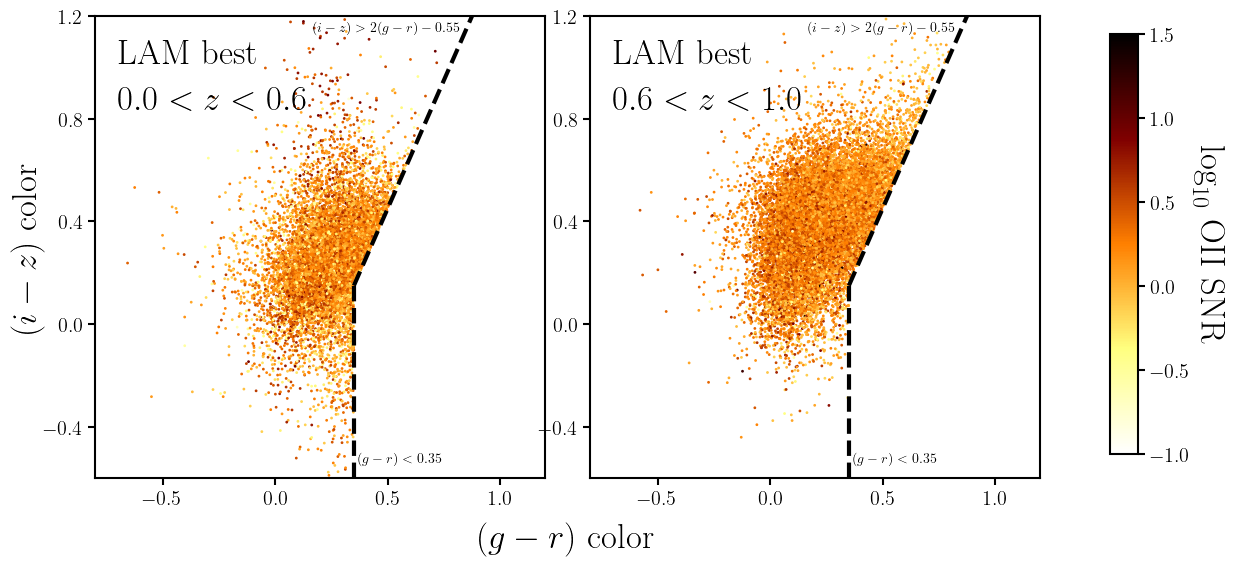

In [20]:
fig = plt.figure(figsize=(14, 6))
for i in range(2): 
    sub = fig.add_subplot(1,2,i+1)

    zlim = ((lam1d['redshift'] > [0.6, 1.][i]) & (lam1d['redshift'] < [1., 1.6][i]) & best_lam & ~mask_oii)

    hb = sub.scatter(
        (g_mag - r_mag)[zlim], # (g-r)
        (i_mag - z_mag)[zlim], # (i-z)
        c=np.log10(oii_snr[zlim]), s=1, vmin=-1, vmax=1.5, cmap='afmhot_r')

    sub.text(0.05, 0.95, r'LAM best', ha='left', va='top', transform=sub.transAxes, fontsize=25)
    sub.text(0.05, 0.85, r'$%.1f < z < %.1f$' % ([0, 0.6, 1., 1.6][i], [0.6, 1., 1.6, 2.4][i]), ha='left', va='top', transform=sub.transAxes, fontsize=25)
    
    sub.plot([0.35, 0.35], [-0.6, 0.15], c='k', ls='--', lw=3)
    sub.plot([0.35, 1.275], [0.15, 2], c='k', ls='--', lw=3)
    
    sub.text(0.37, -0.5, '$(g-r) < 0.35$', ha='left', va='top', fontsize=10)
    sub.text(0.825, 1.18, '$(i-z) > 2 (g-r) - 0.55$', ha='right', va='top', fontsize=10)
    sub.set_xlim(-0.8, 1.2)
    sub.set_ylim(-0.6, 1.2)
    sub.set_yticks([-0.4, 0., 0.4, 0.8, 1.2])

bkgd = fig.add_subplot(111, frameon=False)
bkgd.set_xlabel(r'$(g - r)$ color', labelpad=10, fontsize=25) 
bkgd.set_ylabel(r'$(i - z)$ color', labelpad=10, fontsize=25) 
bkgd.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
fig.subplots_adjust(wspace=0.1, right=0.8)

cbar_ax = fig.add_axes([0.85, 0.15, 0.02, 0.7])
cbar = fig.colorbar(hb, cax=cbar_ax)
cbar.ax.set_ylabel(r'$\log_{10}$ OII SNR', labelpad=25, fontsize=25, rotation=270)

12933
17958


Text(0, 0.5, '$N_{\\rm z}$')

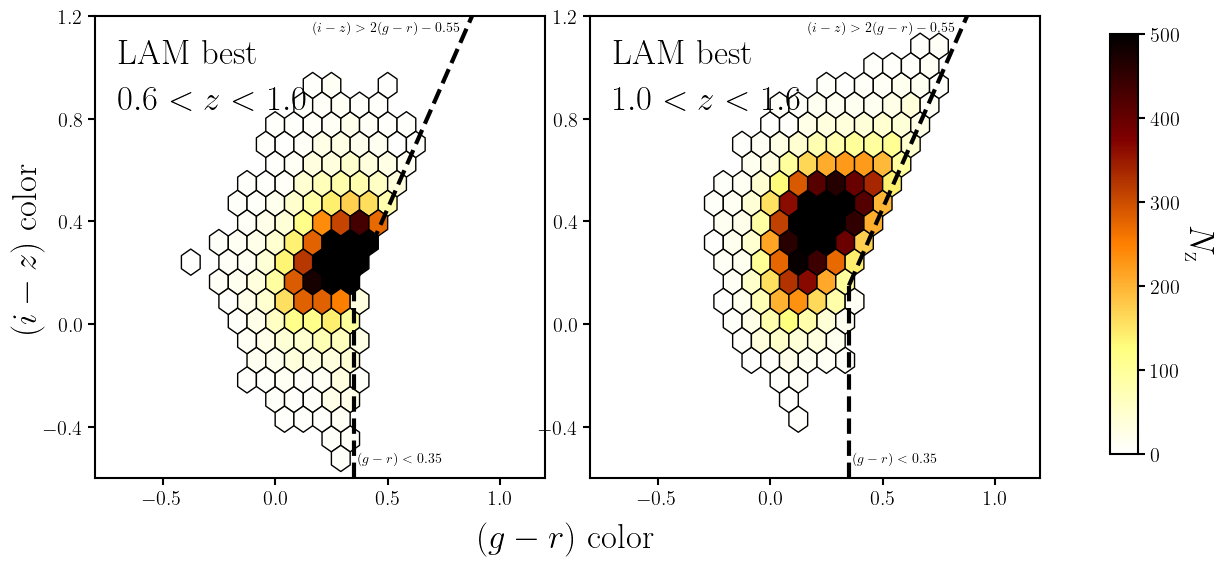

In [21]:
fig = plt.figure(figsize=(14, 6))
for i in range(2): 
    sub = fig.add_subplot(1,2,i+1)

    zlim = ((lam1d['redshift'] > [0.6, 1.][i]) & (lam1d['redshift'] < [1., 1.6][i]))# & best_lam & ~mask_oii)
    print(np.sum(zlim & best_lam))

    hb = sub.hexbin(
        (g_mag - r_mag)[zlim], # (g-r)
        (i_mag - z_mag)[zlim], # (i-z)
        C=(best_lam & ~mask_oii).astype(float)[zlim], 
        edgecolors='k', linewidth=1., reduce_C_function=np.sum, 
        extent=(-1, 1.5, -0.6, 2), gridsize=30, vmin=0., vmax=500., mincnt=5, cmap='afmhot_r')

    sub.text(0.05, 0.95, r'LAM best', ha='left', va='top', transform=sub.transAxes, fontsize=25)
    sub.text(0.05, 0.85, r'$%.1f < z < %.1f$' % ([0.6, 1.][i], [1., 1.6][i]), ha='left', va='top', transform=sub.transAxes, fontsize=25)
    
    sub.plot([0.35, 0.35], [-0.6, 0.15], c='k', ls='--', lw=3)
    sub.plot([0.35, 1.275], [0.15, 2], c='k', ls='--', lw=3)
    
    sub.text(0.37, -0.5, '$(g-r) < 0.35$', ha='left', va='top', fontsize=10)
    sub.text(0.825, 1.18, '$(i-z) > 2 (g-r) - 0.55$', ha='right', va='top', fontsize=10)
    sub.set_xlim(-0.8, 1.2)
    sub.set_ylim(-0.6, 1.2)
    sub.set_yticks([-0.4, 0., 0.4, 0.8, 1.2])

bkgd = fig.add_subplot(111, frameon=False)
bkgd.set_xlabel(r'$(g - r)$ color', labelpad=10, fontsize=25) 
bkgd.set_ylabel(r'$(i - z)$ color', labelpad=10, fontsize=25) 
bkgd.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
fig.subplots_adjust(wspace=0.1, right=0.8)

cbar_ax = fig.add_axes([0.85, 0.15, 0.02, 0.7])
cbar = fig.colorbar(hb, cax=cbar_ax)
cbar.ax.set_ylabel(r'$N_{\rm z}$', labelpad=25, fontsize=25, rotation=270)

In [22]:
# scale OII SNR down based on exposure time
oii_snr_scaled = oii_snr / np.sqrt(lam1d_oii['t_exp_total'] / 900.)

Text(0, 0.5, '$N_{\\rm z}$')

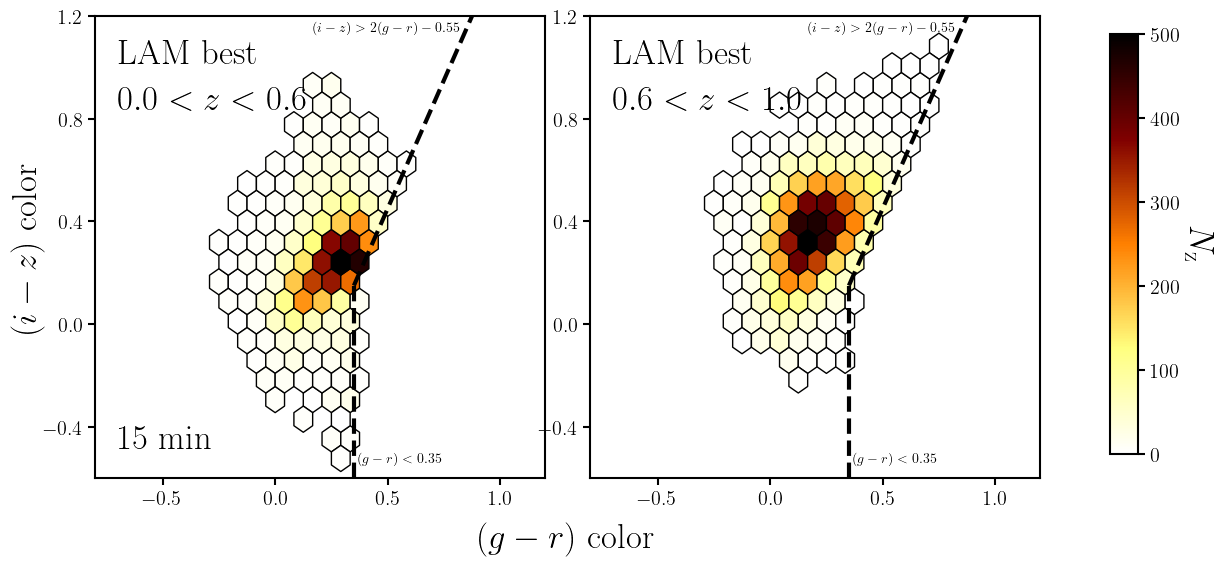

In [26]:
snr_cut = oii_snr_scaled > 10**0.2

fig = plt.figure(figsize=(14, 6))
for i in range(2): 
    sub = fig.add_subplot(1,2,i+1)

    zlim = ((lam1d['redshift'] > [0.6, 1.][i]) & (lam1d['redshift'] < [1., 1.6][i]))# & best_lam & ~mask_oii)

    hb = sub.hexbin(
        (g_mag - r_mag)[zlim], # (g-r)
        (i_mag - z_mag)[zlim], # (i-z)
        C=(best_lam & ~mask_oii & snr_cut).astype(float)[zlim], 
        edgecolors='k', linewidth=1., reduce_C_function=lambda x: 2*np.sum(x), 
        extent=(-1, 1.5, -0.6, 2), gridsize=30, vmin=0., vmax=500., mincnt=5, cmap='afmhot_r')

    if i == 0:    
        sub.text(0.05, 0.05, r'15 min', ha='left', va='bottom', transform=sub.transAxes, fontsize=25)

    sub.text(0.05, 0.95, r'LAM best', ha='left', va='top', transform=sub.transAxes, fontsize=25)
    sub.text(0.05, 0.85, r'$%.1f < z < %.1f$' % ([0, 0.6, 1., 1.6][i], [0.6, 1., 1.6, 2.4][i]), ha='left', va='top', transform=sub.transAxes, fontsize=25)
    
    sub.plot([0.35, 0.35], [-0.6, 0.15], c='k', ls='--', lw=3)
    sub.plot([0.35, 1.275], [0.15, 2], c='k', ls='--', lw=3)
    
    sub.text(0.37, -0.5, '$(g-r) < 0.35$', ha='left', va='top', fontsize=10)
    sub.text(0.825, 1.18, '$(i-z) > 2 (g-r) - 0.55$', ha='right', va='top', fontsize=10)
    sub.set_xlim(-0.8, 1.2)
    sub.set_ylim(-0.6, 1.2)
    sub.set_yticks([-0.4, 0., 0.4, 0.8, 1.2])

bkgd = fig.add_subplot(111, frameon=False)
bkgd.set_xlabel(r'$(g - r)$ color', labelpad=10, fontsize=25) 
bkgd.set_ylabel(r'$(i - z)$ color', labelpad=10, fontsize=25) 
bkgd.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
fig.subplots_adjust(wspace=0.1, right=0.8)

cbar_ax = fig.add_axes([0.85, 0.15, 0.02, 0.7])
cbar = fig.colorbar(hb, cax=cbar_ax)
cbar.ax.set_ylabel(r'$N_{\rm z}$', labelpad=25, fontsize=25, rotation=270)

Text(0, 0.5, '$N_{\\rm z}$(15min)/$N_{\\rm z}$(30min)')

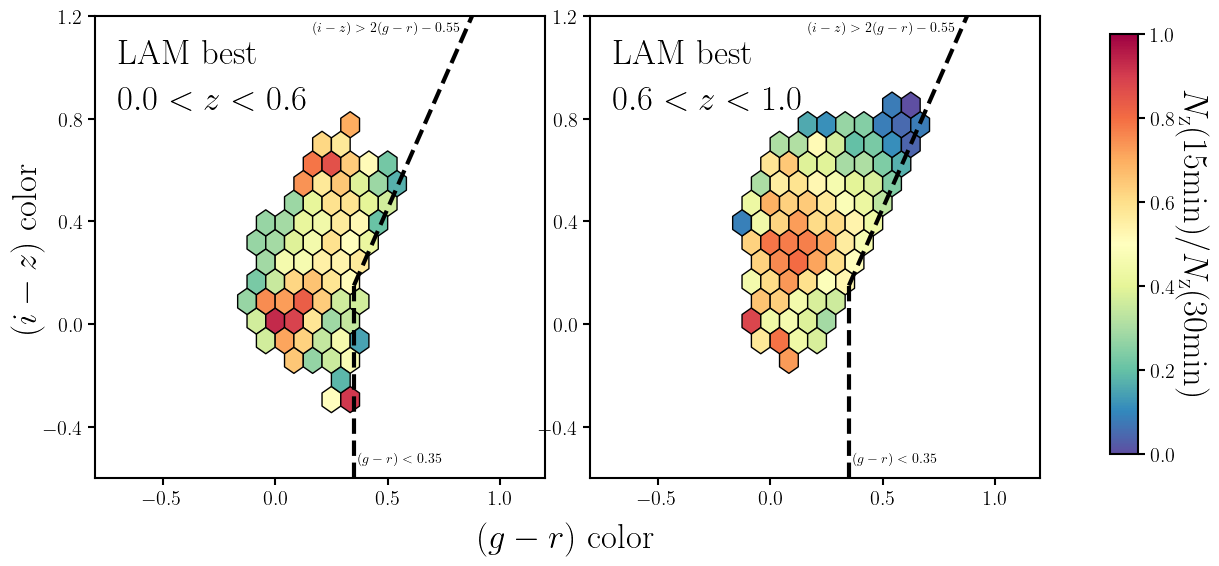

In [32]:
fig = plt.figure(figsize=(14, 6))
for i in range(2): 
    sub = fig.add_subplot(1,2,i+1)

    zlim = ((lam1d['redshift'] > [0.6, 1.][i]) & (lam1d['redshift'] < [1., 1.6][i]))# & best_lam & ~mask_oii)

    hb = sub.hexbin(
        (g_mag - r_mag)[zlim & best_lam & ~mask_oii], # (g-r)
        (i_mag - z_mag)[zlim & best_lam & ~mask_oii], # (i-z)
        C=snr_cut.astype(float)[zlim & best_lam & ~mask_oii], 
        edgecolors='k', linewidth=1., reduce_C_function=lambda x: 2 * np.mean(x), 
        extent=(-1, 1.5, -0.6, 2), gridsize=30, vmin=0., vmax=1., mincnt=20, cmap='Spectral_r')

    sub.text(0.05, 0.95, r'LAM best', ha='left', va='top', transform=sub.transAxes, fontsize=25)
    sub.text(0.05, 0.85, r'$%.1f < z < %.1f$' % ([0, 0.6, 1., 1.6][i], [0.6, 1., 1.6, 2.4][i]), ha='left', va='top', transform=sub.transAxes, fontsize=25)
    
    sub.plot([0.35, 0.35], [-0.6, 0.15], c='k', ls='--', lw=3)
    sub.plot([0.35, 1.275], [0.15, 2], c='k', ls='--', lw=3)
    
    sub.text(0.37, -0.5, '$(g-r) < 0.35$', ha='left', va='top', fontsize=10)
    sub.text(0.825, 1.18, '$(i-z) > 2 (g-r) - 0.55$', ha='right', va='top', fontsize=10)
    sub.set_xlim(-0.8, 1.2)
    sub.set_ylim(-0.6, 1.2)
    sub.set_yticks([-0.4, 0., 0.4, 0.8, 1.2])

bkgd = fig.add_subplot(111, frameon=False)
bkgd.set_xlabel(r'$(g - r)$ color', labelpad=10, fontsize=25) 
bkgd.set_ylabel(r'$(i - z)$ color', labelpad=10, fontsize=25) 
bkgd.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
fig.subplots_adjust(wspace=0.1, right=0.8)

cbar_ax = fig.add_axes([0.85, 0.15, 0.02, 0.7])
cbar = fig.colorbar(hb, cax=cbar_ax)
cbar.ax.set_ylabel(r'$N_{\rm z}$(15min)/$N_{\rm z}$(30min)', labelpad=25, fontsize=25, rotation=270)

In [33]:
np.median(hb.get_array())

np.float64(0.45788336933045354)